FOR EXAM

PRIOR, LIKELIHOOD AND BAYES' THEOREM FOR GMMS AND GET THE RESPONSIBILTIES. UNDERSTAND WHAT HAPPENS DURING THE E AND M STEPS. UNDERSTAND THE CONVERGENCE BEHAVIOR OF EM.

# Gaussian Mixture Models

A single Gaussian is a poor model for data that forms several separate clusters. A **Gaussian Mixture Model (GMM)** fixes this by modeling the density of a sample $\boldsymbol{x} \in \mathbb{R}^D$ as a *weighted sum* of $K$ Gaussians:
$$p(\boldsymbol{x}) = \sum_{k=1}^K \pi_k\,\mathcal{N}(\boldsymbol{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

Like K-Means, a GMM groups data into $K$ components — but instead of a hard assignment to the nearest centroid, every point belongs to *all* components with some probability (a *soft* assignment), and each component has its own shape via a full covariance matrix.

**This notebook covers:**
1. Fitting a GMM with the **Expectation-Maximization (EM)** algorithm, implemented from scratch
2. Visualizing the fitted density and how it evolves over the EM iterations
3. Discussion questions on the convergence behavior of EM

## Imports and helper functions

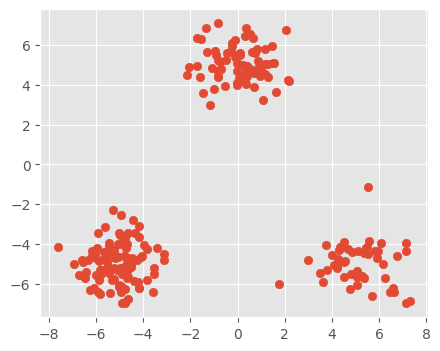

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import rcParams
from scipy.stats import multivariate_normal

rcParams['figure.figsize'] = (5, 4)
plt.style.use('ggplot')

def get_data():
    np.random.seed(42)
    # Three clusters with different sizes and centers.
    x1 = np.random.normal(size=(100, 2)) + np.array([-5, -5])
    x2 = np.random.normal(size=(50, 2)) + np.array([5, -5])
    x3 = np.random.normal(size=(75, 2)) + np.array([0, 5])
    X = np.vstack((x1, x2, x3))
    return X

X = get_data()
plt.scatter(X[:, 0], X[:, 1])
plt.show()

## The Gaussian Mixture Model

The GMM describes the density of a sample $\boldsymbol{x} \in \mathbb{R}^D$ as
$$p(\boldsymbol{x}) = \sum_{k=1}^K \pi_k\,\mathcal{N}(\boldsymbol{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

**Symbol glossary:**
- $K$: number of mixture components (clusters)
- $\pi_k \geq 0$, with $\sum_k \pi_k = 1$: **mixing coefficients** — the prior probability that a point belongs to component $k$
- $\boldsymbol{\mu}_k \in \mathbb{R}^D$: **mean** of the $k$-th Gaussian
- $\boldsymbol{\Sigma}_k \in \mathbb{R}^{D \times D}$: **covariance matrix** of the $k$-th Gaussian (sets the shape and orientation of the component)

The goal is to find $\{\pi_k, \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k\}_{k=1}^K$ that best explain the observed data. Because we don't know which component generated each point, we can't solve this in closed form — instead we use the **EM algorithm**.

## The EM Algorithm for GMMs

The **Expectation-Maximization (EM)** algorithm alternates two steps until convergence.

**E-step — compute responsibilities:**
$$r_{nk} = \frac{\pi_k\,\mathcal{N}(\boldsymbol{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^K \pi_j\,\mathcal{N}(\boldsymbol{x}_n \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$
The **responsibility** $r_{nk}$ is the probability that sample $n$ was generated by component $k$. By construction $\sum_k r_{nk} = 1$ for each $n$ (a soft assignment).

**M-step — update parameters:** using the effective number of points per component $N_k = \sum_n r_{nk}$,
$$\boldsymbol{\mu}_k^\text{new} = \frac{1}{N_k}\sum_{n=1}^N r_{nk}\,\boldsymbol{x}_n \qquad \boldsymbol{\Sigma}_k^\text{new} = \frac{1}{N_k}\sum_{n=1}^N r_{nk}(\boldsymbol{x}_n - \boldsymbol{\mu}_k)(\boldsymbol{x}_n - \boldsymbol{\mu}_k)^\top \qquad \pi_k^\text{new} = \frac{N_k}{N}$$

**Key properties of EM:**
- The negative log-likelihood (NLL) is **guaranteed not to increase** at any iteration.
- EM can converge to a **local** optimum — the result depends on the initialization.
- We run a fixed number of iterations here and record the NLL after each one (revisited in the discussion questions).

---

**Python note — `multivariate_normal`:** `scipy.stats.multivariate_normal(mean, cov).pdf(X)` evaluates the Gaussian density at every row of `X` at once, returning a 1-D array of length `N`. We multiply it by $\pi_k$ to get the weighted contribution of component $k$.

**Python note — the responsibility matrix `R`:** we store responsibilities as an array of shape `(N, K)` — one row per sample, one column per component. Computing the densities for all components gives the same `(N, K)` shape; dividing each row by its sum normalizes it so the row sums to 1. `np.sum(R, axis=1, keepdims=True)` keeps the result as an `(N, 1)` column so it **broadcasts** cleanly across the `K` columns during the division.

**Python note — `R.T @ X` in the M-step:** the weighted-mean update $\sum_n r_{nk}\boldsymbol{x}_n$ for all components at once is exactly the matrix product `R.T @ X` (shape `(K, D)`). Dividing by `N_k[:, np.newaxis]` rescales each component's row.

**Python note — the `1e-8` terms:** tiny constants are added to `N_k` (to avoid dividing by zero if a component becomes empty) and to the diagonal of each covariance matrix (to keep it invertible). This is standard numerical "jitter", not part of the math.

**Python note — leading underscores:** helper methods such as `_expectation`, `_maximization`, and `_set_inital_parameters` start with an underscore to mark them as *internal* — the public interface is `fit`, `predict`, `density`.

> **Implement the GMM with the EM algorithm** by completing the class skeleton below.

In [6]:
class GMM:
    """A GMM which is fitted through the EM-algorithm.

    Args:
        K (int): Number of components to be specified.
        n_iterations (int): Number of iterations of performing the EM algorithm.
        random_state (int): Random state to ensure reproducibility.

    """
    def __init__(self, K=3, n_iterations=10, random_state=5):
        self.K = K
        self.n_iterations = n_iterations
        self.random_state = random_state
        self._mu_history = []
        self._Sigma_history = []
        self._pi_history = []

    def density(self, X):
        """Computes component-wise densities of given samples.

        Args:
            X (array-like):  Samples whose densities are to be computed with shape (N, D).

        Returns:
            ndarray:  Computed densities per sample and component with shape (N, K).
        """
####################
# Your Code Here   #
####################
        N, D = X.shape
        densities = np.zeros((N, self.K))
        for k in range(self.K):
            densities[:, k] = self.pi[k] * multivariate_normal.pdf(X, mean=self.mu[k], cov=self.sigma[k])
        return densities


    def negative_log_likelihood(self, X):
        """Computes negative loglikelihood (NLL) for given samples.

        Args:
            X (array-like): Samples for which NLL is to be computed with shape (N, D).

        Returns:
            float: Computed negative log-likelihood.
        """
####################
# Your Code Here   #
####################
        likelihood = np.sum(np.log(np.sum(self.density(X), axis=1)))
        return -likelihood

    def fit(self, X, y=None):
        """Fits the GMM by performing the EM-algorithm.

        Args:
            X (array-like): Training samples with shape (N, D).

        Returns:
            self: The fitted GMM.
        """
####################
# Your Code Here   #
####################
        self._set_inital_parameters()
        for _ in range(self.n_iterations):
            R = self._expectation(X)
            self._maximization(X, R)
        return self

    def predict(self, X):
        """Predicts components with highest responsibility per sample.

        Args:
            X (array-like): Samples whose most likely components are to be predicted with shape (N, D).


        Returns:
            ndarray:  Most likely components from which the samples were generated with shape (N).
        """
####################
# Your Code Here   #
####################
        return np.argmax(self._expectation(X), axis=1)
    def predict_proba(self, X):
        """Predicts responsibilities of given samples.

        Args:
            X (array-like): Samples (N, D) whose responsibilities are to be computed.

        Returns:
            array-like: Computed responsibilities with shape (N, K).

        """
####################
# Your Code Here   #
####################
        return self._expectation(X)

    def _set_inital_parameters(self):
        """ Initializes the parameters of the GMM randomly. """
        # Defines random state for reproducibility.
        random_state = np.random.RandomState(self.random_state)
####################
# Your Code Here   #
####################
        # Initialize the mixing coefficients uniformly.
        self.pi = np.ones(self.K) / self.K
        # Randomly initialize the means by sampling from the data.
        N, D = X.shape
        self.mu = X[random_state.choice(N, self.K, replace=False)]
        # Initialize the covariance matrices as identity matrices.
        self.sigma = np.array([np.eye(D) for _ in range(self.K)])
        
    def _expectation(self, X):
        """Implements E-step by computing responsibilities.

        Args:
            X (array-like): Samples whose responsibilities are to be computed with shape (N, D).


        Returns:
            array-like: Computed responsibilities with shape (N, K).

        """
        ####################
        # Your Code Here   #
        ####################
        densities = self.density(X)
        responsibilities = densities / np.sum(densities, axis=1, keepdims=True)
        return responsibilities
        

    def _maximization(self, X, R):
        """Implements M-step by updating GMM parameters.

        Args:
            X (array-like): Samples whose responsibilities are to be computed with shape (N, D).
            R (array-like): Responsibilities of samples with (N, K).

        """
        ####################
        # Your Code Here   #
        ####################
        self._mu_history.append(self.mu.copy())
        self._Sigma_history.append(self.sigma.copy())
        self._pi_history.append(self.pi.copy())
        for k in range(self.K):
            Nk = np.sum(R[:, k])
            rnk = R[:, k][:, np.newaxis]
            xn = rnk * X
            muk = np.sum(xn, axis=0) / Nk
            self.mu[k] = muk
            self.sigma[k] = (rnk * (X - muk)).T @ (X - muk) / Nk

> **Fit the GMM and plot the resulting density.** Use `plt.contour` together with the provided meshgrid to overlay the mixture density, and color the scatter points by their most likely component (`gmm.predict`).

A meshgrid `pos` of evaluation points is provided. `gmm.density(pos)` returns the weighted density of each component (shape `(n_points, K)`); summing over the last axis with `.sum(-1)` gives the full mixture density $p(\boldsymbol{x})$.

**What to look for:**
- Each contour ring is a line of constant density — tighter rings mark higher-density regions.
- Each component should roughly wrap around one cluster.
- If components collapse together, try a different `random_state` — EM is sensitive to initialization.

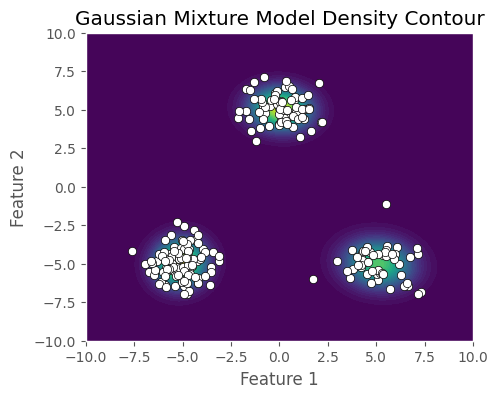

In [7]:
X_mesh, Y_mesh = np.meshgrid(np.linspace(-10, 10, 100), np.linspace(-10, 10, 100))
pos = np.column_stack([X_mesh.ravel(), Y_mesh.ravel()])

####################
# Your Code Here   #
####################
gmm = GMM(K=3, n_iterations=5, random_state=42)
gmm.fit(X)
Z = gmm.density(pos).sum(axis=1).reshape(X_mesh.shape)
plt.contourf(X_mesh, Y_mesh, Z, levels=50, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c='white', edgecolor='black')
plt.title('Gaussian Mixture Model Density Contour')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

> **Visualize how the density evolves over the EM iterations.** During `fit`, the GMM stored the parameters after every iteration in `gmm._mu_history`, `gmm._Sigma_history`, and `gmm._pi_history`. Loop over that history and draw the mixture density at each step in its own subplot.

**What to look for:**
- The first panel shows the (poor) random initialization — the components sit almost on top of each other.
- Over successive iterations the components spread out and each settles onto one cluster, showing EM steadily improving the fit.

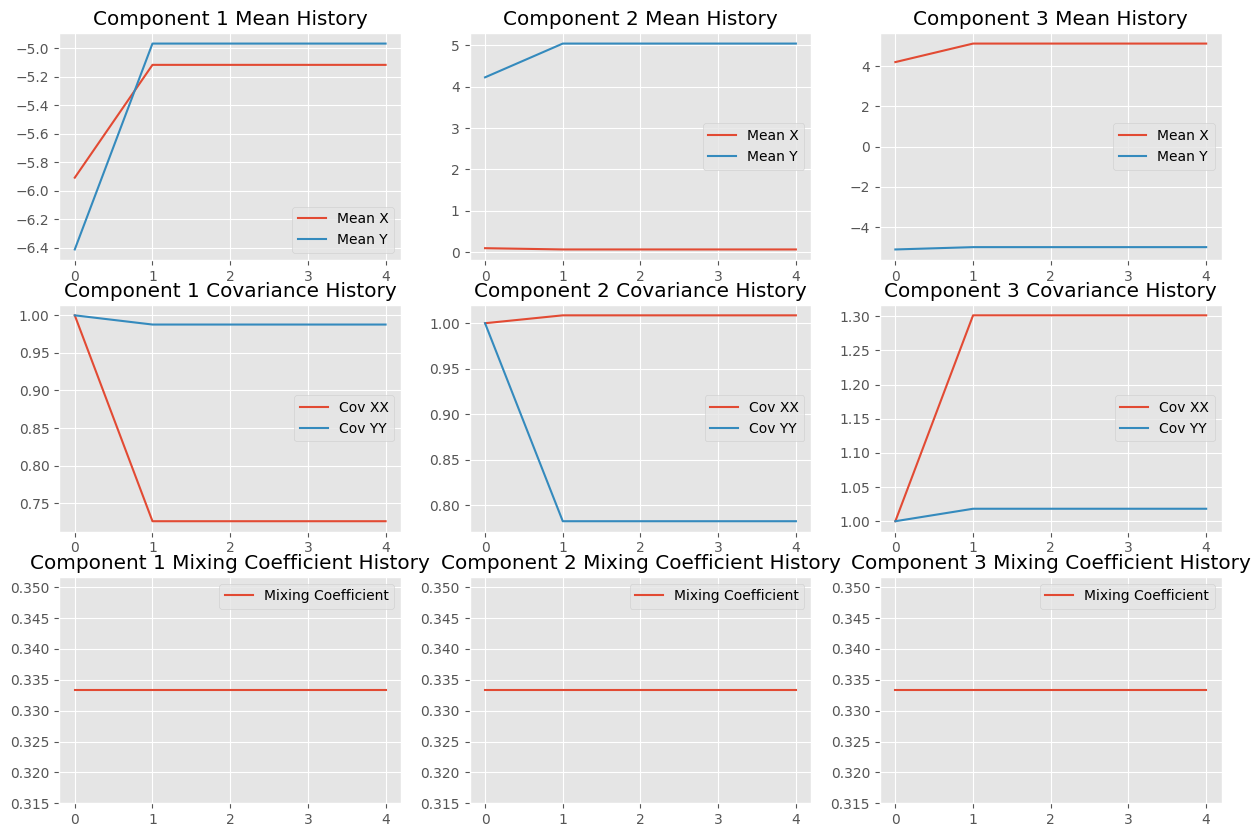

In [8]:
####################
# Your Code Here   #
####################

fig, axes = plt.subplots(3, gmm.K, figsize=(15, 10))
for k in range(gmm.K):
    axes[0, k].plot([mu[k][0] for mu in gmm._mu_history], label='Mean X')
    axes[0, k].plot([mu[k][1] for mu in gmm._mu_history], label='Mean Y')
    axes[0, k].set_title(f'Component {k+1} Mean History')
    axes[0, k].legend()
    
    axes[1, k].plot([sigma[k][0, 0] for sigma in gmm._Sigma_history], label='Cov XX')
    axes[1, k].plot([sigma[k][1, 1] for sigma in gmm._Sigma_history], label='Cov YY')
    axes[1, k].set_title(f'Component {k+1} Covariance History')
    axes[1, k].legend()
    
    axes[2, k].plot([pi[k] for pi in gmm._pi_history], label='Mixing Coefficient')
    axes[2, k].set_title(f'Component {k+1} Mixing Coefficient History')
    axes[2, k].legend()

#### **Discussion questions**

1. Can the NLL increase while performing the EM algorithm?
It will always decrease or stay the same. This is because in the E-step, we compute the responsibilities based on the current parameters and in the M-step, we update the parameters to maximize the expected likelihood given those responsibilities. This guarantees that the NLL will not increase at any iteration.

2. Is the EM algorithm for the GMM guaranteed to converge?
Yes, the EM algorithm is guaranteed to converge to a local optimum of the likelihood function. However, it is not guaranteed to find the global optimum, and the convergence can depend on the initialization of the parameters. This comes from the Lower Bound property of EM, which ensures that the likelihood will not decrease with each iteration, but it does not guarantee that it will reach the global maximum.

3. How can we use the NLL as a criterion for stopping the training of the GMM?
We can check if the NLL converges by monitoring its value at each iteration. If the change in NLL between iterations is smaller than a threshold we can stop training.
